# Gaussian Copula Correlation -- Annual and Seasonal

Methodology visual: the (24x24) Gaussian-copula correlation matrix of probit-transformed
baseline-forecaster residuals over the 2018 training year -- one panel for the full year
(the matrix actually frozen and used for scenario generation, `Sigma` in
`5_scenario_gen/frozen_copula.pkl`) plus one panel per meteorological season (diagnostic
only, not frozen -- included here to show how the dependence structure shifts across the
year).

Directly reuses `5_scenario_gen/copula_lib.py`'s estimation functions
(`MarginalDistCDF`, `build_probit_matrix`, `seasonal_correlation_matrices`) -- the same
code path `copula_testing_neat_final.ipynb` Section 4 uses -- rather than
reimplementing anything, so this figure is guaranteed consistent with the actual frozen
artefact.

## Setup

In [1]:
from __future__ import annotations
import sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pyprojroot import here

ROOT_DIR = here()
FORECASTING_DIR = ROOT_DIR / "4_forecasting"
COPULA_DIR = ROOT_DIR / "5_scenario_gen"
DATA_DIR = ROOT_DIR / "1_data" / "processed"

sys.path.insert(0, str(FORECASTING_DIR))
sys.path.insert(0, str(COPULA_DIR))

from forecasting import (
    QUANTILE_LEVELS, HIST_COLS, FEAT_COLS, EXO_COLS, TRAIN_START, VAL_START,
    build_features, reindex_and_impute, make_windows,
    normalise_hist, normalise_exo, denormalise_y, Baseline_Forecaster,
)
from copula_lib import build_probit_matrix, seasonal_correlation_matrices

device = torch.device("cpu")
print(f"training-year window: {TRAIN_START} -> {VAL_START}")

training-year window: 2018-01-01 00:00:00+00:00 -> 2019-01-01 00:00:00+00:00


### Load data and the frozen baseline forecaster

Same reconstruction as `copula_testing_neat_final.ipynb` Section 2 -- the checkpoint's
own `scaler_stats`/`model_config` are the single source of truth, so this uses exactly
what the forecaster was trained with.

In [2]:
base_data = pd.read_csv(DATA_DIR / "df_full.csv", parse_dates=["datetime"]).set_index("datetime")
base_data = reindex_and_impute(base_data, HIST_COLS, freq="1h", warn_gap=6)
frame_full = build_features(base_data, feature_cols=FEAT_COLS)
print(f"frame_full: {frame_full.shape} | {frame_full.index.min()} -> {frame_full.index.max()}")

forecaster_checkpoint = torch.load(FORECASTING_DIR / "baseline_forecaster_best.pt", weights_only=False, map_location="cpu")
sc = forecaster_checkpoint["scaler_stats"]

model = Baseline_Forecaster(**forecaster_checkpoint["model_config"])
model.load_state_dict(forecaster_checkpoint["state_dict"])
model = model.to(device).eval()

[impute] 66 missing values across ['prosumption', 'solar_irrad', 'panel_temp', 'ambient_temp'] after reindex
[impute]   prosumption: 20 missing, longest run 11h   <-- LONG GAP (review)
[impute]   panel_temp: 46 missing, longest run 19h   <-- LONG GAP (review)
frame_full: (23520, 11) | 2017-11-03 00:00:00+00:00 -> 2020-07-09 23:00:00+00:00


### Gate-aligned 2018 training-year windows and quantile forecasts

Same window construction as the original notebook's Section 3 (`gate_aligned_only=True,
issue_hour=9`, one window per delivery day, full 2018 training year) -- the same origin
scheme the frozen copula was actually estimated on.

In [3]:
h = pd.Timedelta(hours=1)
copula_windows = make_windows(
    frame_full, y_range=(TRAIN_START, VAL_START - h),
    gate_aligned_only=True, issue_hour=9,
    exo_cols=EXO_COLS, hist_cols=HIST_COLS, target_col="prosumption",
)
n_days = len(copula_windows.delivery_start)
print(f"n_days={n_days}  first={copula_windows.delivery_start[0]}  last={copula_windows.delivery_start[-1]}")


def forecast_quantiles(x_hist_day, x_fut_day):
    with torch.no_grad():
        xh = torch.as_tensor(normalise_hist(np.asarray(x_hist_day), sc), dtype=torch.float32, device=device).unsqueeze(0)
        xf = torch.as_tensor(normalise_exo(np.asarray(x_fut_day), sc), dtype=torch.float32, device=device).unsqueeze(0)
        q_norm = model(xh, xf)
        q_phys = denormalise_y(q_norm, sc)
    return q_phys.squeeze(0).cpu().numpy()   # (24, 19)


q_mw = np.stack([
    forecast_quantiles(copula_windows.x_hist[d], copula_windows.x_fut[d])
    for d in range(n_days)
], axis=0)   # (N, 24, 19)
y = np.asarray(copula_windows.y, dtype=float)   # (N, 24)
print(f"q_mw.shape={q_mw.shape}  y.shape={y.shape}")

n_days=365  first=2018-01-01 00:00:00+00:00  last=2018-12-31 00:00:00+00:00
q_mw.shape=(365, 24, 19)  y.shape=(365, 24)


### Probit scores and correlation matrices

`build_probit_matrix` (PIT + probit of the realised errors) turns the raw forecasts into
standard-normal scores whose correlation is the Gaussian-copula dependence matrix --
identical to Section 4.1/4.2 of the original notebook. The freshly computed annual matrix
is checked against the actually-frozen `year_corr_matrix.npy` as a consistency check.

In [4]:
X = build_probit_matrix(y, q_mw, levels=QUANTILE_LEVELS)
year_corr_matrix = np.corrcoef(X, rowvar=False)   # (24, 24) -- the frozen annual matrix

frozen_year_corr = np.load(COPULA_DIR / "year_corr_matrix.npy")
max_abs_diff = np.abs(year_corr_matrix - frozen_year_corr).max()
print(f"max |recomputed - frozen| annual correlation entry = {max_abs_diff:.2e} "
      f"({'matches' if max_abs_diff < 1e-6 else 'DOES NOT MATCH'} the frozen artefact)")

seasonal_mats = seasonal_correlation_matrices(X, dates=copula_windows.delivery_start)

max |recomputed - frozen| annual correlation entry = 0.00e+00 (matches the frozen artefact)
Winter: 90 days
Spring: 92 days
Summer: 92 days
Autumn: 91 days


## Annual and seasonal copula correlation, one figure

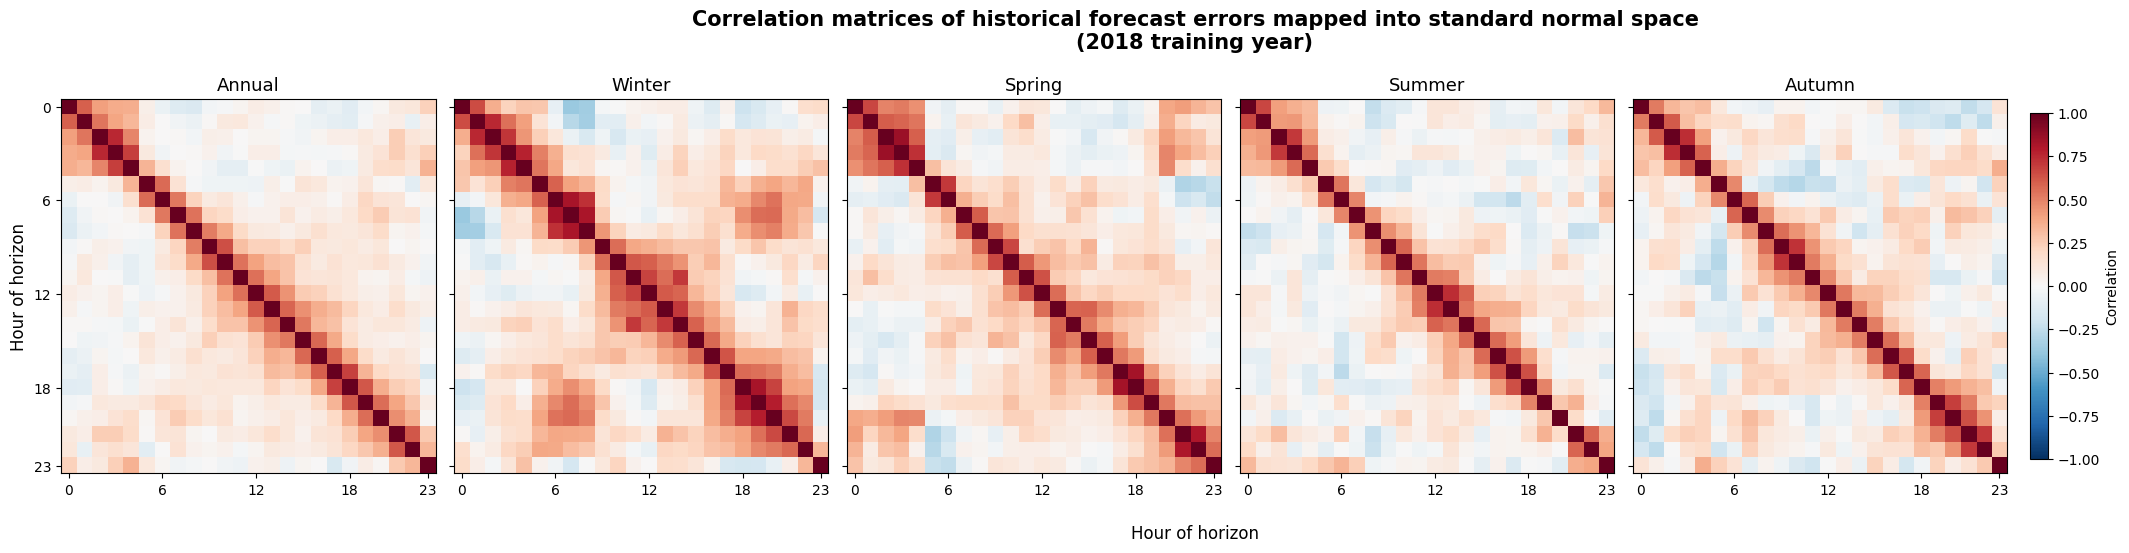

In [12]:
import matplotlib.pyplot as plt

PANEL_ORDER = ["Annual", "Winter", "Spring", "Summer", "Autumn"]
PANELS = {"Annual": year_corr_matrix, **seasonal_mats}

# 1. UPDATED: Added sharex=True and sharey=True to clean up redundant inner axis labels
fig, axes = plt.subplots(1, 5, figsize=(24, 5.5), sharex=True, sharey=True)
im = None

for ax, name in zip(axes, PANEL_ORDER):
    # 2. UPDATED: aspect="equal" strictly enforces perfect squares
    im = ax.imshow(PANELS[name], vmin=-1, vmax=1, cmap="RdBu_r", origin="upper", aspect="equal")
    ax.set_title(name, fontsize=13)
    
    # 3. UPDATED: Removed individual ax.set_xlabel() calls
    
    # 4. UPDATED: Set natural 6-hour visual blocks for daily profile consistency
    ax.set_xticks([0, 6, 12, 18, 23])
    ax.set_yticks([0, 6, 12, 18, 23])

# 5. UPDATED: Capitalized the y-axis label
axes[0].set_ylabel("Hour of horizon", fontsize=12)

# 6. UPDATED: Created a single, centralized x-axis label for the whole figure
fig.supxlabel("Hour of horizon", fontsize=12)

# 7. UPDATED: Formalized title with a line break and parenthesis instead of "--"
fig.suptitle(
    "Correlation matrices of historical forecast errors mapped into standard normal space\n"
    "(2018 training year)", 
    fontsize=15, fontweight="bold"
)

# 9. UPDATED: Added a rect to prevent the suptitle and supxlabel from clipping the subplots
fig.tight_layout(rect=[0, 0.02, 1, 0.98])
fig.colorbar(im, ax=axes.tolist(), shrink=0.85, pad=0.01, label="Correlation")
plt.show()

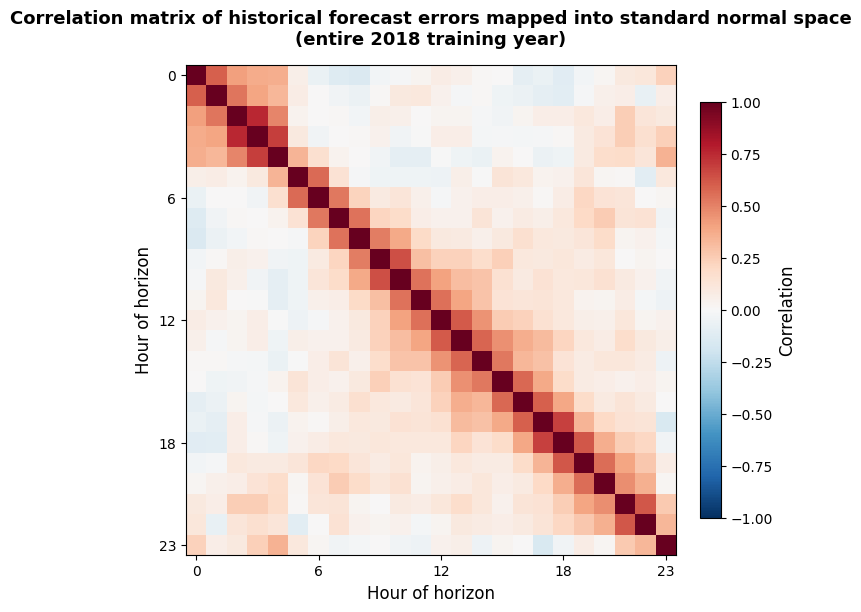

In [13]:
import matplotlib.pyplot as plt

# (Assuming PANELS dictionary is already defined in your environment)
# For example: year_corr_matrix = PANELS["Annual"]

fig, ax = plt.subplots(figsize=(7, 6))

# 1. Plot the single heatmap
im = ax.imshow(
    PANELS["Annual"], 
    vmin=-1, 
    vmax=1, 
    cmap="RdBu_r", 
    origin="upper", 
    aspect="equal"
)

# 2. Maintain the consistent 6-hour time blocks
ax.set_xticks([0, 6, 12, 18, 23])
ax.set_yticks([0, 6, 12, 18, 23])

# 3. Apply standard axis labels directly to the single axis
ax.set_xlabel("Hour of horizon", fontsize=12)
ax.set_ylabel("Hour of horizon", fontsize=12)

# 4. Combine the main title and subtitle into one clean heading
ax.set_title(
    "Correlation matrix of historical forecast errors mapped into standard normal space\n"  
    "(entire 2018 training year)", 
    fontsize=13, 
    fontweight="bold",
    pad=15
)

# 5. Attach the colorbar directly to the single plot
cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.04)
cbar.set_label("Correlation", fontsize=12)

fig.tight_layout()
plt.show()